# Gap Distance Limit Analysis

Systematic evaluation of gap-crossing performance for trained high-level
vision policies (MLP and RNN architectures). Sweeps fixed gap distances
from 0.02 m to 0.50 m, measuring:

1. **Crossing success rate** (psychometric-style curves)
2. **Forward progress** (torso x position at episode end)
3. **Survival time** (steps before termination)

Three checkpoints are compared:

| Run ID | Architecture | Target speed | Gap range (training) |
|---|---|---|---|
| `260311_140506` | MLP (binocular shared CNN) | 0.8 m/s | 0.06 -- 0.20 m |
| `260312_232009` | RNN (binocular CNN+GRU)   | 0.7 m/s | 0.03 -- 0.40 m |
| `260313_231545` | MLP (binocular shared CNN) | 1.0 m/s | 0.06 -- 0.40 m |

In [1]:
%load_ext autoreload
%autoreload 2

import os

os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.5"

import vnl_playground.naccdmax_patch

[naccdmax_patch] Patched warp make_data/put_data: naccdmax defaults to naconmax


In [2]:
import gc
import json
from collections import OrderedDict
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import orbax.checkpoint as ocp
from omegaconf import OmegaConf
from tqdm import tqdm

from track_mjx.agent.ff_ppo import ppo_networks as ff_ppo_networks
from track_mjx.agent.observation_utils import init_dict_normalizer
from track_mjx.agent.checkpointing import _replace_zero_sized_arrays
from track_mjx.agent.recurrent_ppo import networks as recurrent_ppo_networks
from track_mjx.agent.recurrent_ppo.recurrent_binocular_vision_networks import (
    make_recurrent_binocular_vision_highlvl_ppo_networks,
)

from vnl_playground import tasks
from vnl_playground.tasks.wrappers import PriorHighLevelWrapper
from vnl_playground.tasks.prior_utils import (
    load_prior_checkpoint,
    make_decoder_inference_fn,
    make_prior_inference_fn,
)
from vnl_playground.tasks.rodent.vision_jax import (
    JaxVisionRenderer,
    VisionRenderWrapper,
)

print(f"JAX devices: {jax.devices()}")
print(f"JAX backend: {jax.default_backend()}")

JAX devices: [CudaDevice(id=0)]
JAX backend: gpu


## 1. Configuration

Define checkpoint paths, gap distances to sweep, and evaluation parameters.

In [14]:
# ---------------------------------------------------------------------------
# Checkpoint definitions
# ---------------------------------------------------------------------------
BASE_DIR = Path("/home/talmolab/Desktop/SalkResearch/vnl-playground")
CKPT_DIR = BASE_DIR / "highlvl_checkpoints"

CHECKPOINTS = OrderedDict(
    {
        "260311_140506": {
            "label": "MLP v=0.8",
            "arch": "mlp",
            "color": "#1f77b4",
        },
        "260312_232009": {
            "label": "RNN v=0.7",
            "arch": "rnn",
            "color": "#ff7f0e",
        },
        # "260313_231545": {
        #     "label": "MLP v=1.0",
        #     "arch": "mlp",
        #     "color": "#2ca02c",
        # },
    }
)

# ---------------------------------------------------------------------------
# Gap sweep parameters
# ---------------------------------------------------------------------------
GAP_DISTANCES = np.round(np.arange(0.02, 0.52, 0.02), 3)  # 0.02 to 0.50 m
N_ENVS = 64  # All rollouts run in parallel via Warp multi-world          # parallel rollouts per gap distance
EPISODE_LENGTH = 500  # steps per rollout (at ctrl_dt ~ 10-20 ms => 5-10 s)
SEED = 42

print(f"Gap distances ({len(GAP_DISTANCES)}): {GAP_DISTANCES.tolist()}")
print(f"Parallel rollouts per distance: {N_ENVS}")
print(f"Episode length: {EPISODE_LENGTH} steps")

Gap distances (25): [0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2, 0.22, 0.24, 0.26, 0.28, 0.3, 0.32, 0.34, 0.36, 0.38, 0.4, 0.42, 0.44, 0.46, 0.48, 0.5]
Parallel rollouts per distance: 64
Episode length: 500 steps


## 2. Load Prior Checkpoint (shared across all models)

All three checkpoints use the same SCAMPER prior decoder. Load it once.

In [4]:
PRIOR_CKPT_PATH = "/home/talmolab/Desktop/SalkResearch/data/prior"

(
    encoder_params,
    prior_params,
    decoder_params,
    normalizer_params,
    prior_cfg,
) = load_prior_checkpoint(PRIOR_CKPT_PATH, step=None)

latent_size = prior_cfg["network_config"]["intention_size"]
prior_ctrl_dt = prior_cfg.get("env_config", {}).get("ctrl_dt", None)

prior_fn = make_prior_inference_fn(prior_params, normalizer_params, prior_cfg)
decoder_policy_fn = make_decoder_inference_fn(
    decoder_params, normalizer_params, prior_cfg
)

print(f"Prior latent (intention) size: {latent_size}")
print(f"Prior ctrl_dt: {prior_ctrl_dt}")

Prior latent (intention) size: 16
Prior ctrl_dt: 0.01


## 3. Helper Functions

Utilities for loading checkpoints, building environments, and running rollouts.

In [5]:
from mujoco.mjx.warp.types import DATA_NON_VMAP


def _add_batch_dim_for_warp(data):
    """Add leading batch dim to MJX Data, skipping non-vmap fields.

    MJX Warp's FFI layer expects contact/efc fields to remain unbatched.
    """

    def _maybe_expand(path, x):
        parts = [p.name for p in path if hasattr(p, "name") and p.name != "_impl"]
        attr = "__".join(parts)
        if attr in DATA_NON_VMAP:
            return x
        return x[None, ...]

    return jax.tree.map_with_path(_maybe_expand, data)


def load_checkpoint_config(run_id: str) -> dict:
    """Load the JSON config for a given checkpoint run."""
    with open(CKPT_DIR / run_id / "config.json") as f:
        return json.load(f)


def build_env_for_gap(
    config: dict,
    gap_dist: float,
    prior_ctrl_dt: float | None = None,
    n_envs: int = 1,
) -> object:
    """Create an environment with a fixed gap distance.

    Args:
        config: Checkpoint config dict.
        gap_dist: Fixed gap distance in meters.
        prior_ctrl_dt: Control timestep from prior checkpoint.
        n_envs: Number of parallel worlds (scales naconmax).

    Returns:
        Raw (unwrapped) MjxEnv environment.
    """
    env_args = dict(config["env_config"]["env_args"])
    env_args["gap_length_range"] = [gap_dist, gap_dist]

    # Enforce ctrl_dt from prior
    if prior_ctrl_dt is not None:
        env_args["ctrl_dt"] = float(prior_ctrl_dt)

    # Scale naconmax for multi-world (12 contacts per world is typical)
    # Warp broadphase needs ~18 contacts per world; use generous headroom
    env_args["naconmax"] = max(512, n_envs * 48)

    # Pass vision config
    for key in ("vision_width", "vision_height", "grayscale", "binocular"):
        if key in config["env_config"]:
            env_args[key] = config["env_config"][key]

    env = tasks.load(
        config["env_config"]["env_name"],
        flatten_obs=False,
        config_overrides=env_args,
    )
    return env


def wrap_env_with_prior(
    env, config: dict, prior_fn, decoder_policy_fn, latent_size: int
):
    """Wrap raw env with PriorHighLevelWrapper for policy evaluation."""
    highlvl_obs_key = config["transfer"].get("highlvl_obs_key", "task_obs")
    decoder_obs_key = config["transfer"].get("decoder_obs_key", "proprioception")
    deterministic_prior = config["transfer"].get("deterministic_prior", True)

    return PriorHighLevelWrapper(
        env,
        prior_fn,
        decoder_policy_fn,
        latent_size,
        highlvl_obs_key=highlvl_obs_key,
        decoder_obs_key=decoder_obs_key,
        pass_vision=True,
        pass_task_obs=True,
        deterministic_prior=deterministic_prior,
    )


def make_vision_renderers(env, config: dict, n_envs: int = 1):
    """Create left and right JaxVisionRenderer instances.

    Args:
        env: The environment (possibly wrapped).
        config: Checkpoint config dict.
        n_envs: Number of parallel worlds for batched rendering.

    Returns:
        Tuple of (left_renderer, right_renderer).
    """
    # Unwrap to get raw env with mj_model / mjx_model
    raw_env = env
    while hasattr(raw_env, "env"):
        raw_env = raw_env.env

    vision_width = config["env_config"].get("vision_width", 32)
    vision_height = config["env_config"].get("vision_height", 32)
    grayscale = config["env_config"].get("grayscale", True)
    left_camera = config["env_config"].get("left_camera_name", "eye_left-rodent")
    right_camera = config["env_config"].get("right_camera_name", "eye_right-rodent")
    render_depth = config["env_config"].get("render_depth", False)
    use_textures = config["env_config"].get("use_textures", False)
    use_shadows = config["env_config"].get("use_shadows", False)

    renderer_kwargs = dict(
        nworld=n_envs,
        width=vision_width,
        height=vision_height,
        grayscale=grayscale,
        render_depth=render_depth,
        use_textures=use_textures,
        use_shadows=use_shadows,
    )

    left_renderer = JaxVisionRenderer(
        mj_model=raw_env.mj_model,
        mjx_model=raw_env.mjx_model,
        camera_name=left_camera,
        **renderer_kwargs,
    )
    right_renderer = JaxVisionRenderer(
        mj_model=raw_env.mj_model,
        mjx_model=raw_env.mjx_model,
        camera_name=right_camera,
        **renderer_kwargs,
    )
    return left_renderer, right_renderer


print("Helper functions defined.")

Helper functions defined.


In [6]:
def build_mlp_network(config: dict, obs_sizes: dict, action_size: int):
    """Build the binocular shared-CNN MLP PPO network from config.

    Returns:
        Tuple of (ppo_network, shared_module).
    """
    ncfg = config["network_config"]
    mono_channels = 1 if config["env_config"].get("grayscale", True) else 3
    binocular_mode = ncfg.get("binocular_mode", "shared")
    vision_shape = (
        config["env_config"].get("vision_height", 32),
        config["env_config"].get("vision_width", 32),
        2 * mono_channels,
    )

    ppo_network, shared_module = (
        ff_ppo_networks.make_binocular_shared_vision_task_obs_highlvl_ppo_networks(
            obs_sizes=obs_sizes,
            action_size=action_size,
            vision_shape=vision_shape,
            mono_channels=mono_channels,
            shared_weights=(binocular_mode == "shared"),
            vision_latent_size=ncfg["vision_latent_size"],
            vision_feature_size=ncfg.get("vision_feature_size", 32),
            decoder_hidden_layer_sizes=tuple(ncfg["decoder_hidden_layer_sizes"]),
            value_hidden_layer_sizes=tuple(ncfg["value_hidden_layer_sizes"]),
            vision_channels=tuple(ncfg["vision_channels"]),
            fusion_hidden_layer_sizes=tuple(
                ncfg.get("fusion_hidden_layer_sizes", [256])
            ),
        )
    )
    return ppo_network, shared_module


def build_rnn_network(config: dict, obs_sizes: dict, action_size: int):
    """Build the recurrent binocular CNN+GRU PPO network from config.

    Returns:
        Tuple of (recurrent_ppo_network, shared_module).
    """
    ncfg = config["network_config"]
    mono_channels = 1 if config["env_config"].get("grayscale", True) else 3
    binocular_mode = ncfg.get("binocular_mode", "shared")
    vision_shape = (
        config["env_config"].get("vision_height", 32),
        config["env_config"].get("vision_width", 32),
        2 * mono_channels,
    )

    recurrent_ppo_network, shared_module = (
        make_recurrent_binocular_vision_highlvl_ppo_networks(
            obs_sizes=obs_sizes,
            action_size=action_size,
            vision_shape=vision_shape,
            cnn_feature_size=ncfg.get("vision_feature_size", 32),
            cnn_channels=tuple(ncfg["vision_channels"]),
            gru_hidden_size=ncfg.get("gru_hidden_size", 256),
            mono_channels=mono_channels,
            shared_weights=(binocular_mode == "shared"),
            policy_hidden_sizes=tuple(ncfg.get("policy_head_sizes", [256])),
            value_hidden_sizes=tuple(ncfg.get("value_head_sizes", [256, 128])),
        )
    )
    return recurrent_ppo_network, shared_module


def load_mlp_params(run_id: str, ppo_network, obs_sizes: dict):
    """Load MLP policy params from orbax checkpoint.

    Returns:
        params_tuple: (normalizer_params, policy_params) for inference.
    """
    ckpt_dir = CKPT_DIR / run_id

    ckpt_mgr = ocp.CheckpointManager(
        str(ckpt_dir),
        options=ocp.CheckpointManagerOptions(
            save_interval_steps=1,
            max_to_keep=50,
            step_prefix="PPONetwork",
            create=False,
        ),
    )
    latest_step = ckpt_mgr.latest_step()

    # Build abstract template for restore
    key_policy = jax.random.PRNGKey(0)
    init_policy_params = ppo_network.policy_network.init(key_policy)
    dummy_obs = {k: jnp.zeros((1, v)) for k, v in obs_sizes.items()}
    abstract_policy = _replace_zero_sized_arrays(
        (init_dict_normalizer(dummy_obs), init_policy_params)
    )

    normalizer_params, policy_params = ckpt_mgr.restore(
        latest_step,
        args=ocp.args.Composite(policy=ocp.args.StandardRestore(abstract_policy)),
    )["policy"]

    print(f"  Loaded MLP checkpoint step {latest_step} from {run_id}")
    return (normalizer_params, policy_params)


def load_rnn_params(run_id: str, recurrent_ppo_network, obs_sizes: dict):
    """Load RNN policy params from orbax checkpoint.

    Returns:
        params_tuple: (normalizer_params, policy_params) for inference.
    """
    ckpt_dir = CKPT_DIR / run_id

    ckpt_mgr = ocp.CheckpointManager(
        str(ckpt_dir),
        options=ocp.CheckpointManagerOptions(
            save_interval_steps=1,
            max_to_keep=50,
            step_prefix="PPONetwork",
            create=False,
        ),
    )
    latest_step = ckpt_mgr.latest_step()

    # Build abstract template for restore
    key_policy = jax.random.PRNGKey(0)
    init_policy_params = recurrent_ppo_network.policy_network.init(key_policy)
    dummy_obs = {k: jnp.zeros((1, v)) for k, v in obs_sizes.items()}
    abstract_policy = _replace_zero_sized_arrays(
        (init_dict_normalizer(dummy_obs), init_policy_params)
    )

    normalizer_params, policy_params = ckpt_mgr.restore(
        latest_step,
        args=ocp.args.Composite(policy=ocp.args.StandardRestore(abstract_policy)),
    )["policy"]

    print(f"  Loaded RNN checkpoint step {latest_step} from {run_id}")
    return (normalizer_params, policy_params)


print("Network and checkpoint functions defined.")

Network and checkpoint functions defined.


In [7]:
def _render_binocular(data, left_renderer, right_renderer):
    """Render binocular vision for batched data. Returns (N, H, W, 2C)."""
    left = left_renderer.render(data)
    right = right_renderer.render(data)
    return jnp.concatenate([left, right], axis=-1)


def _inject_vision_batched(obs, vision):
    """Replace the vision placeholder in a batched obs dict."""
    return {k: (vision if k == "vision" else v) for k, v in obs.items()}


def run_batched_mlp_rollout(
    wrapped_env,
    left_renderer,
    right_renderer,
    inference_fn,
    params_tuple,
    n_envs: int,
    episode_length: int,
    seed: int,
):
    """Run n_envs parallel MLP rollouts using Warp multi-world rendering.

    All environments step in parallel via jax.vmap; vision is rendered
    for all worlds in a single Warp call (nworld=n_envs).

    Returns:
        Dict with per-env metrics (arrays of length n_envs).
    """
    base_reset = wrapped_env.reset
    base_step = wrapped_env.step
    vmapped_reset = jax.vmap(base_reset)
    vmapped_step = jax.vmap(base_step)

    def eval_reset(rngs):
        states = vmapped_reset(rngs)
        vision = _render_binocular(states.data, left_renderer, right_renderer)
        return states.replace(obs=_inject_vision_batched(states.obs, vision))

    def eval_step(states, actions):
        states = vmapped_step(states, actions)
        vision = _render_binocular(states.data, left_renderer, right_renderer)
        return states.replace(obs=_inject_vision_batched(states.obs, vision))

    jit_reset = jax.jit(eval_reset)
    jit_step = jax.jit(eval_step)

    # Reset all envs in parallel
    rngs = jax.random.split(jax.random.PRNGKey(seed), n_envs)
    states = jit_reset(rngs)

    act_rng = jax.random.PRNGKey(seed + 999)

    # Accumulate per-step metrics
    all_rewards = []
    all_dones = []
    all_torso_xs = []

    for _ in range(episode_length):
        _, act_rng = jax.random.split(act_rng)
        actions, _ = inference_fn(params_tuple, states.obs, act_rng)
        states = jit_step(states, actions)
        all_rewards.append(states.reward)  # (N,)
        all_dones.append(states.done)  # (N,)
        all_torso_xs.append(states.data.qpos[:, 0])  # (N,) root freejoint x

    # Stack to (T, N)
    rewards = jnp.stack(all_rewards)
    dones = jnp.stack(all_dones)
    torso_xs = jnp.stack(all_torso_xs)

    # -- Per-env aggregation (handling early termination) --
    # Mask: True for timesteps AFTER the first done
    first_done_mask = jnp.cumsum(dones, axis=0)
    # Include the done step itself in reward, but not subsequent steps
    active_mask = first_done_mask <= 1  # True for steps up to and including first done

    any_done = jnp.any(dones, axis=0)  # (N,)
    first_done_step = jnp.argmax(dones, axis=0)  # (N,) - index of first done
    n_steps = jnp.where(any_done, first_done_step + 1, episode_length)
    total_reward = jnp.sum(rewards * active_mask, axis=0)
    max_x = jnp.max(torso_xs * active_mask + (-1e6) * (~active_mask), axis=0)

    # Gap crossings from environment state (final value)
    gaps_crossed = states.info.get("gaps_crossed", jnp.zeros(n_envs))

    return {
        "n_steps": np.array(n_steps),
        "total_reward": np.array(total_reward),
        "max_x": np.array(max_x),
        "gaps_crossed": np.array(gaps_crossed),
    }


def run_batched_rnn_rollout(
    wrapped_env,
    left_renderer,
    right_renderer,
    inference_fn,
    params_tuple,
    init_hidden_fn,
    n_envs: int,
    episode_length: int,
    seed: int,
):
    """Run n_envs parallel RNN rollouts with GRU hidden state management.

    All environments step in parallel via jax.vmap; vision is rendered
    for all worlds in a single Warp call.

    Returns:
        Dict with per-env metrics (arrays of length n_envs).
    """
    base_reset = wrapped_env.reset
    base_step = wrapped_env.step
    vmapped_reset = jax.vmap(base_reset)
    vmapped_step = jax.vmap(base_step)

    def eval_reset(rngs):
        states = vmapped_reset(rngs)
        vision = _render_binocular(states.data, left_renderer, right_renderer)
        return states.replace(obs=_inject_vision_batched(states.obs, vision))

    def eval_step(states, actions):
        states = vmapped_step(states, actions)
        vision = _render_binocular(states.data, left_renderer, right_renderer)
        return states.replace(obs=_inject_vision_batched(states.obs, vision))

    jit_reset = jax.jit(eval_reset)
    jit_step = jax.jit(eval_step)

    # Reset all envs in parallel
    rngs = jax.random.split(jax.random.PRNGKey(seed), n_envs)
    states = jit_reset(rngs)

    # Initialize hidden state for all envs: (N, gru_hidden_size)
    hidden = init_hidden_fn(n_envs)

    act_rng = jax.random.PRNGKey(seed + 999)

    all_rewards = []
    all_dones = []
    all_torso_xs = []

    for _ in range(episode_length):
        _, act_rng = jax.random.split(act_rng)
        actions, _, new_hidden = inference_fn(params_tuple, states.obs, hidden, act_rng)
        hidden = new_hidden
        states = jit_step(states, actions)
        all_rewards.append(states.reward)
        all_dones.append(states.done)
        all_torso_xs.append(states.data.qpos[:, 0])

    rewards = jnp.stack(all_rewards)
    dones = jnp.stack(all_dones)
    torso_xs = jnp.stack(all_torso_xs)

    first_done_mask = jnp.cumsum(dones, axis=0)
    active_mask = first_done_mask <= 1

    any_done = jnp.any(dones, axis=0)
    first_done_step = jnp.argmax(dones, axis=0)
    n_steps = jnp.where(any_done, first_done_step + 1, episode_length)
    total_reward = jnp.sum(rewards * active_mask, axis=0)
    max_x = jnp.max(torso_xs * active_mask + (-1e6) * (~active_mask), axis=0)
    gaps_crossed = states.info.get("gaps_crossed", jnp.zeros(n_envs))

    return {
        "n_steps": np.array(n_steps),
        "total_reward": np.array(total_reward),
        "max_x": np.array(max_x),
        "gaps_crossed": np.array(gaps_crossed),
    }


print("Batched rollout functions defined.")

Batched rollout functions defined.


In [8]:
def run_gap_sweep_for_checkpoint(
    run_id: str,
    arch: str,
    gap_distances,
    n_envs: int,
    episode_length: int,
    seed: int,
):
    """Run the full gap distance sweep for one checkpoint.

    For each gap distance, creates ONE environment and runs n_envs
    rollouts IN PARALLEL using Warp multi-world rendering.

    Args:
        run_id: Checkpoint run ID.
        arch: "mlp" or "rnn".
        gap_distances: Array of gap distances to test.
        n_envs: Number of parallel rollouts per gap distance.
        episode_length: Max steps per rollout.
        seed: Base random seed.

    Returns:
        Dict mapping gap distance to aggregated metrics.
    """
    config = load_checkpoint_config(run_id)
    print(f"\n{'='*60}")
    print(f"Checkpoint: {run_id} ({arch.upper()})")
    print(f"{'='*60}")

    # ---- Build a reference environment to get obs_sizes / action_size ----
    ref_env = build_env_for_gap(config, gap_distances[0], prior_ctrl_dt, n_envs=1)
    ref_wrapped = wrap_env_with_prior(
        ref_env, config, prior_fn, decoder_policy_fn, latent_size
    )
    obs_sizes = ref_wrapped.observation_size
    action_size = ref_wrapped.action_size
    print(f"  obs_sizes: {obs_sizes}")
    print(f"  action_size (latent): {action_size}")
    del ref_env, ref_wrapped

    # ---- Build network and load params (once per checkpoint) ----
    if arch == "mlp":
        ppo_network, _ = build_mlp_network(config, obs_sizes, action_size)
        params_tuple = load_mlp_params(run_id, ppo_network, obs_sizes)
        make_policy = ff_ppo_networks.make_logging_inference_fn(ppo_network)
        inference_fn = jax.jit(make_policy(deterministic=True))
        init_hidden_fn = None
    elif arch == "rnn":
        recurrent_ppo_network, _ = build_rnn_network(config, obs_sizes, action_size)
        params_tuple = load_rnn_params(run_id, recurrent_ppo_network, obs_sizes)
        make_policy = recurrent_ppo_networks.make_logging_inference_fn(
            recurrent_ppo_network
        )
        inference_fn = jax.jit(make_policy(deterministic=True))
        init_hidden_fn = recurrent_ppo_network.policy_network.init_hidden
    else:
        raise ValueError(f"Unknown arch: {arch}")

    gc.collect()

    # ---- Sweep gap distances (one batched rollout per distance) ----
    results = {}
    for gap_idx, gap_dist in enumerate(
        tqdm(gap_distances, desc=f"  Gap sweep ({run_id})")
    ):
        # Build ONE env for this gap distance, renderers for n_envs worlds
        raw_env = build_env_for_gap(config, gap_dist, prior_ctrl_dt, n_envs=n_envs)
        wrapped_env = wrap_env_with_prior(
            raw_env, config, prior_fn, decoder_policy_fn, latent_size
        )
        left_renderer, right_renderer = make_vision_renderers(
            raw_env, config, n_envs=n_envs
        )

        gap_seed = seed + gap_idx * 10000

        if arch == "mlp":
            result = run_batched_mlp_rollout(
                wrapped_env,
                left_renderer,
                right_renderer,
                inference_fn,
                params_tuple,
                n_envs,
                episode_length,
                gap_seed,
            )
        else:
            result = run_batched_rnn_rollout(
                wrapped_env,
                left_renderer,
                right_renderer,
                inference_fn,
                params_tuple,
                init_hidden_fn,
                n_envs,
                episode_length,
                gap_seed,
            )

        # Aggregate across the n_envs parallel rollouts
        n_steps_all = result["n_steps"]
        total_reward_all = result["total_reward"]
        max_x_all = result["max_x"]
        gaps_crossed_all = result["gaps_crossed"]

        results[gap_dist] = {
            "mean_steps": float(np.mean(n_steps_all)),
            "std_steps": float(np.std(n_steps_all)),
            "mean_reward": float(np.mean(total_reward_all)),
            "std_reward": float(np.std(total_reward_all)),
            "mean_max_x": float(np.mean(max_x_all)),
            "std_max_x": float(np.std(max_x_all)),
            "survival_rate": float(np.mean(n_steps_all >= episode_length)),
            "crossing_rate": float(np.mean(gaps_crossed_all >= 1)),
            "mean_gaps_crossed": float(np.mean(gaps_crossed_all)),
            "n_rollouts": n_envs,
        }

        del raw_env, wrapped_env, left_renderer, right_renderer
        gc.collect()
        jax.clear_caches()

    return results


print("Gap sweep function defined.")

Gap sweep function defined.


## 4. Run Gap Distance Sweep

Iterate over all checkpoints and gap distances. This is the main
computation cell and will take a while (each gap distance requires
environment construction and N rollouts).

**Note:** For a quick test, reduce `N_ENVS` (e.g. to 4) and/or reduce
the number of gap distances in `GAP_DISTANCES` in the configuration cell.

In [9]:
all_results = {}

for run_id, info in CHECKPOINTS.items():
    results = run_gap_sweep_for_checkpoint(
        run_id=run_id,
        arch=info["arch"],
        gap_distances=GAP_DISTANCES,
        n_envs=N_ENVS,
        episode_length=EPISODE_LENGTH,
        seed=SEED,
    )
    all_results[run_id] = results

    # Free memory between checkpoints
    gc.collect()
    jax.clear_caches()

print("\nAll sweeps complete.")


Checkpoint: 260311_140506 (MLP)
Warp 1.13.0.dev20260302 initialized:
   Git commit: 2675d53530597430af87c7425a1bbb40a2c5453a
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "CPU"
     "cuda:0"   : "NVIDIA GeForce RTX 5090" (31 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/talmolab/.cache/warp/1.13.0.dev20260302
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.
Module mujoco.mjx.warp.ffi 98d2031 load on device 'cuda:0' took 0.27 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.smooth 12773d5 load on device 'cuda:0' took 3.55 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.collision_driver 4d8b905 load on device 'cuda:0' took 0.23 ms  (cached)
Module _nxn_broadphase__locals__kernel_ea6098d7 ea6098d load on device 'cuda:0' took 0.23 ms  (cached)
Module ccd_ker

  Gap sweep (260311_140506):   0%|          | 0/25 [00:00<?, ?it/s]

Module mujoco.mjx.third_party.mujoco_warp._src.render_util 9cda0d9 load on device 'cuda:0' took 0.38 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.io 4ae9eac load on device 'cuda:0' took 1.57 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.bvh 4527052 load on device 'cuda:0' took 0.45 ms  (cached)
Module render__locals___render_megakernel_1d82c591 1d82c59 load on device 'cuda:0' took 0.61 ms  (cached)


  Gap sweep (260311_140506):   4%|▍         | 1/25 [00:22<09:06, 22.77s/it]

Module render__locals___render_megakernel_79963e65 79963e6 load on device 'cuda:0' took 0.64 ms  (cached)


...


Checkpoint: 260312_232009 (RNN)
  obs_sizes: {'imitation_target': 54, 'proprioception': 0}
  action_size (latent): 16
  Loaded RNN checkpoint step 17 from 260312_232009


  Gap sweep (260312_232009): 100%|██████████| 25/25 [15:13<00:00, 36.52s/it]



Checkpoint: 260313_231545 (MLP)
  obs_sizes: {'imitation_target': 54, 'proprioception': 0}
  action_size (latent): 16
  Loaded MLP checkpoint step 39 from 260313_231545


  Gap sweep (260313_231545):   4%|▍         | 1/25 [00:55<22:09, 55.40s/it]


KeyboardInterrupt: 

## 5. Psychometric Curves: Success Rate vs Gap Distance

The central result -- analogous to the psychometric curves in
Liska et al. (eLife 2022) for real rodent gap-crossing experiments.

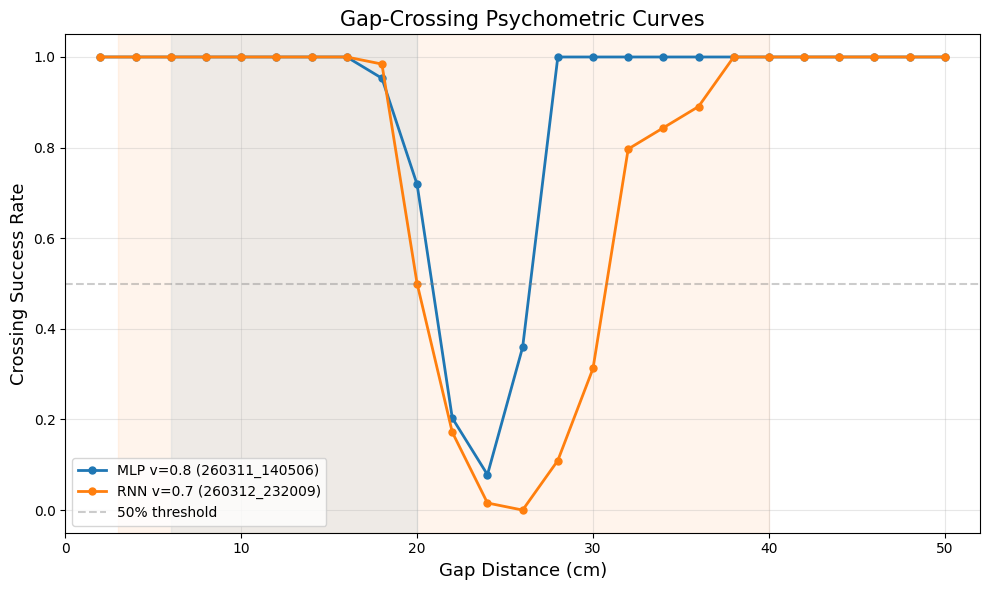

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

for run_id, info in CHECKPOINTS.items():
    if run_id == "260313_231545":
        continue
    results = all_results[run_id]
    gaps = sorted(results.keys())
    crossing_rates = [results[g]["crossing_rate"] for g in gaps]
    gaps_cm = [g * 100 for g in gaps]

    ax.plot(
        gaps_cm,
        crossing_rates,
        "o-",
        color=info["color"],
        label=f'{info["label"]} ({run_id})',
        linewidth=2,
        markersize=5,
    )

# Mark the training gap ranges for each checkpoint
configs = {rid: load_checkpoint_config(rid) for rid in CHECKPOINTS}
for run_id, info in CHECKPOINTS.items():
    cfg = configs[run_id]
    gap_range = cfg["env_config"]["env_args"]["gap_length_range"]
    ax.axvspan(
        gap_range[0] * 100,
        gap_range[1] * 100,
        alpha=0.08,
        color=info["color"],
        label=f"_training range {run_id}",
    )

ax.set_xlabel("Gap Distance (cm)", fontsize=13)
ax.set_ylabel("Crossing Success Rate", fontsize=13)
ax.set_title("Gap-Crossing Psychometric Curves", fontsize=15)
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(0, GAP_DISTANCES.max() * 100 + 2)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4, label="50% threshold")
ax.legend(loc="lower left", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Forward Progress vs Gap Distance

How far does the agent travel before terminating or running out of steps?

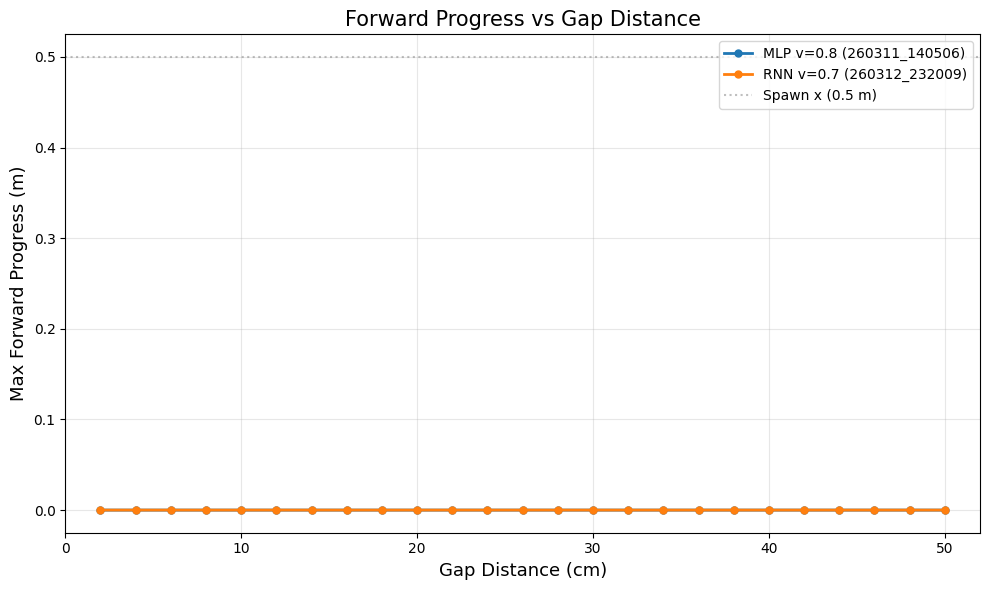

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

for run_id, info in CHECKPOINTS.items():
    results = all_results[run_id]
    gaps = sorted(results.keys())
    mean_x = [results[g]["mean_max_x"] for g in gaps]
    std_x = [results[g]["std_max_x"] for g in gaps]
    gaps_cm = [g * 100 for g in gaps]

    ax.plot(
        gaps_cm,
        mean_x,
        "o-",
        color=info["color"],
        label=f'{info["label"]} ({run_id})',
        linewidth=2,
        markersize=5,
    )
    ax.fill_between(
        gaps_cm,
        np.array(mean_x) - np.array(std_x),
        np.array(mean_x) + np.array(std_x),
        alpha=0.15,
        color=info["color"],
    )

# Reference line: spawn_x (agent starting position)
ax.axhline(y=0.5, color="gray", linestyle=":", alpha=0.5, label="Spawn x (0.5 m)")

ax.set_xlabel("Gap Distance (cm)", fontsize=13)
ax.set_ylabel("Max Forward Progress (m)", fontsize=13)
ax.set_title("Forward Progress vs Gap Distance", fontsize=15)
ax.set_xlim(0, GAP_DISTANCES.max() * 100 + 2)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Survival Time vs Gap Distance

How many timesteps does the agent survive before falling into the gap
or terminating for another reason?

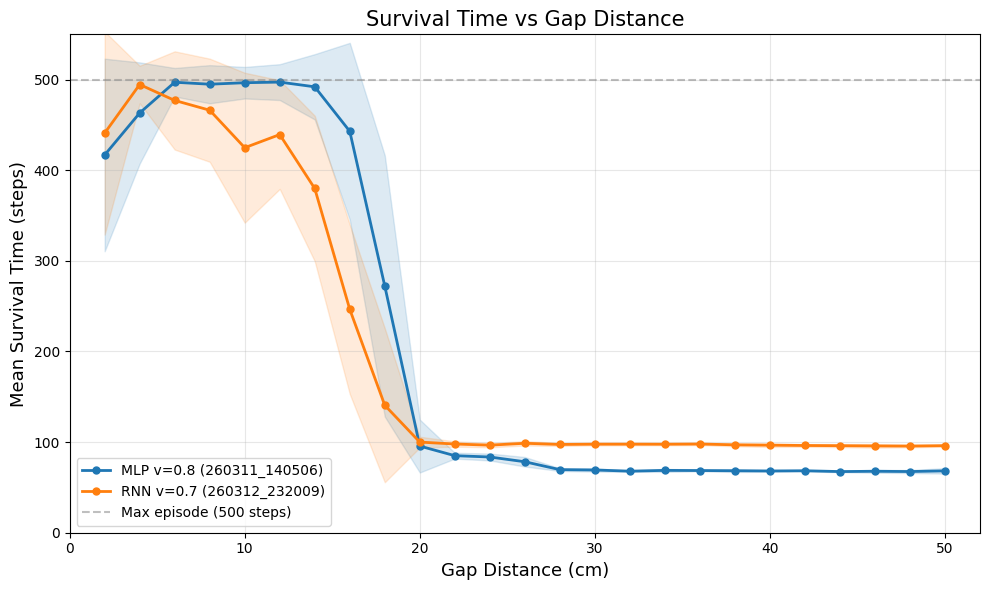

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

for run_id, info in CHECKPOINTS.items():
    results = all_results[run_id]
    gaps = sorted(results.keys())
    mean_steps = [results[g]["mean_steps"] for g in gaps]
    std_steps = [results[g]["std_steps"] for g in gaps]
    gaps_cm = [g * 100 for g in gaps]

    ax.plot(
        gaps_cm,
        mean_steps,
        "o-",
        color=info["color"],
        label=f'{info["label"]} ({run_id})',
        linewidth=2,
        markersize=5,
    )
    ax.fill_between(
        gaps_cm,
        np.array(mean_steps) - np.array(std_steps),
        np.array(mean_steps) + np.array(std_steps),
        alpha=0.15,
        color=info["color"],
    )

ax.axhline(
    y=EPISODE_LENGTH,
    color="gray",
    linestyle="--",
    alpha=0.5,
    label=f"Max episode ({EPISODE_LENGTH} steps)",
)

ax.set_xlabel("Gap Distance (cm)", fontsize=13)
ax.set_ylabel("Mean Survival Time (steps)", fontsize=13)
ax.set_title("Survival Time vs Gap Distance", fontsize=15)
ax.set_xlim(0, GAP_DISTANCES.max() * 100 + 2)
ax.set_ylim(0, EPISODE_LENGTH * 1.1)
ax.legend(loc="lower left", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Combined Summary Figure

Three panels in one figure for publication / presentation.

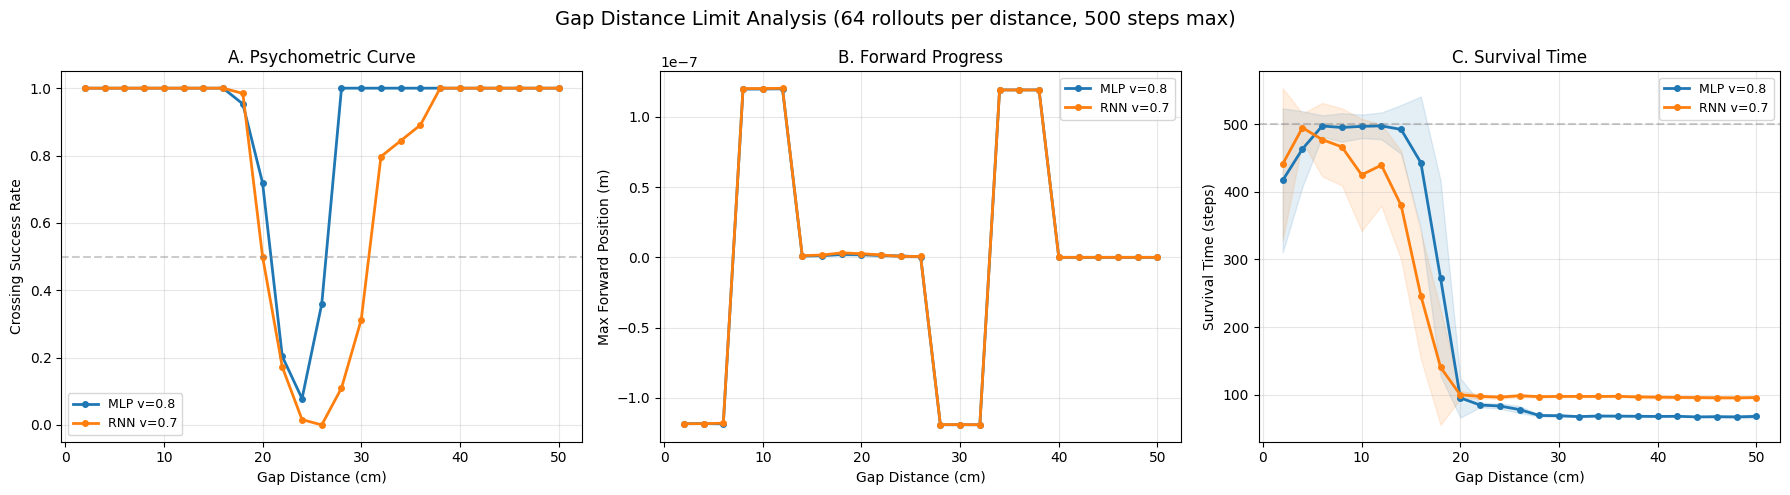

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------- Panel A: Crossing success rate ----------
ax = axes[0]
for run_id, info in CHECKPOINTS.items():
    results = all_results[run_id]
    gaps = sorted(results.keys())
    gaps_cm = [g * 100 for g in gaps]
    crossing_rates = [results[g]["crossing_rate"] for g in gaps]

    ax.plot(
        gaps_cm,
        crossing_rates,
        "o-",
        color=info["color"],
        label=info["label"],
        linewidth=2,
        markersize=4,
    )

ax.set_xlabel("Gap Distance (cm)")
ax.set_ylabel("Crossing Success Rate")
ax.set_title("A. Psychometric Curve")
ax.set_ylim(-0.05, 1.05)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ---------- Panel B: Forward progress ----------
ax = axes[1]
for run_id, info in CHECKPOINTS.items():
    results = all_results[run_id]
    gaps = sorted(results.keys())
    gaps_cm = [g * 100 for g in gaps]
    mean_x = [results[g]["mean_max_x"] for g in gaps]
    std_x = [results[g]["std_max_x"] for g in gaps]

    ax.plot(
        gaps_cm,
        mean_x,
        "o-",
        color=info["color"],
        label=info["label"],
        linewidth=2,
        markersize=4,
    )
    ax.fill_between(
        gaps_cm,
        np.array(mean_x) - np.array(std_x),
        np.array(mean_x) + np.array(std_x),
        alpha=0.12,
        color=info["color"],
    )

ax.set_xlabel("Gap Distance (cm)")
ax.set_ylabel("Max Forward Position (m)")
ax.set_title("B. Forward Progress")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ---------- Panel C: Survival time ----------
ax = axes[2]
for run_id, info in CHECKPOINTS.items():
    results = all_results[run_id]
    gaps = sorted(results.keys())
    gaps_cm = [g * 100 for g in gaps]
    mean_steps = [results[g]["mean_steps"] for g in gaps]
    std_steps = [results[g]["std_steps"] for g in gaps]

    ax.plot(
        gaps_cm,
        mean_steps,
        "o-",
        color=info["color"],
        label=info["label"],
        linewidth=2,
        markersize=4,
    )
    ax.fill_between(
        gaps_cm,
        np.array(mean_steps) - np.array(std_steps),
        np.array(mean_steps) + np.array(std_steps),
        alpha=0.12,
        color=info["color"],
    )

ax.axhline(y=EPISODE_LENGTH, color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel("Gap Distance (cm)")
ax.set_ylabel("Survival Time (steps)")
ax.set_title("C. Survival Time")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Gap Distance Limit Analysis ({N_ENVS} rollouts per distance, "
    f"{EPISODE_LENGTH} steps max)",
    fontsize=14,
)
plt.tight_layout()
plt.show()

## 9. Jump Distance Limit Summary

Identify the maximum gap distance each model can cross with >50% success
(the "jump distance limit").

In [20]:
print("=" * 70)
print("JUMP DISTANCE LIMIT SUMMARY")
print("=" * 70)
print(f"{'Model':<30} {'Arch':<6} {'50% Limit (cm)':<16} {'Max 100% (cm)':<16}")
print("-" * 70)

for run_id, info in CHECKPOINTS.items():
    results = all_results[run_id]
    gaps = sorted(results.keys())
    crossing_rates = [results[g]["crossing_rate"] for g in gaps]

    # Find the largest gap with crossing_rate >= 0.5
    limit_50 = 0.0
    for g, rate in zip(gaps, crossing_rates):
        if rate >= 0.5:
            limit_50 = g

    # Find the largest gap with crossing_rate == 1.0
    limit_100 = 0.0
    for g, rate in zip(gaps, crossing_rates):
        if rate >= 1.0:
            limit_100 = g

    print(
        f'{info["label"]} ({run_id})'
        f'{"":>{30 - len(info["label"]) - len(run_id) - 3}}'
        f'{info["arch"].upper():<6} '
        f"{limit_50 * 100:>6.1f} cm       "
        f"{limit_100 * 100:>6.1f} cm"
    )

print("-" * 70)

# Detailed table per gap distance
print("\n\nDetailed crossing rates per gap distance:")
print(f"{'Gap (cm)':>10}", end="")
for run_id, info in CHECKPOINTS.items():
    print(f"  {info['label']:>14}", end="")
print()
print("-" * (10 + 16 * len(CHECKPOINTS)))

for g in sorted(all_results[list(CHECKPOINTS.keys())[0]].keys()):
    print(f"{g * 100:>10.1f}", end="")
    for run_id in CHECKPOINTS:
        rate = all_results[run_id][g]["crossing_rate"]
        print(f"  {rate:>14.1%}", end="")
    print()

JUMP DISTANCE LIMIT SUMMARY
Model                          Arch   50% Limit (cm)   Max 100% (cm)   
----------------------------------------------------------------------
MLP v=0.8 (260311_140506)     MLP      50.0 cm         50.0 cm
RNN v=0.7 (260312_232009)     RNN      50.0 cm         50.0 cm
----------------------------------------------------------------------


Detailed crossing rates per gap distance:
  Gap (cm)       MLP v=0.8       RNN v=0.7
------------------------------------------
       2.0          100.0%          100.0%
       4.0          100.0%          100.0%
       6.0          100.0%          100.0%
       8.0          100.0%          100.0%
      10.0          100.0%          100.0%
      12.0          100.0%          100.0%
      14.0          100.0%          100.0%
      16.0          100.0%          100.0%
      18.0           95.3%           98.4%
      20.0           71.9%           50.0%
      22.0           20.3%           17.2%
      24.0            7.8%   

## 10. Total Reward vs Gap Distance

Reward integrates both forward velocity and gap crossing bonuses.

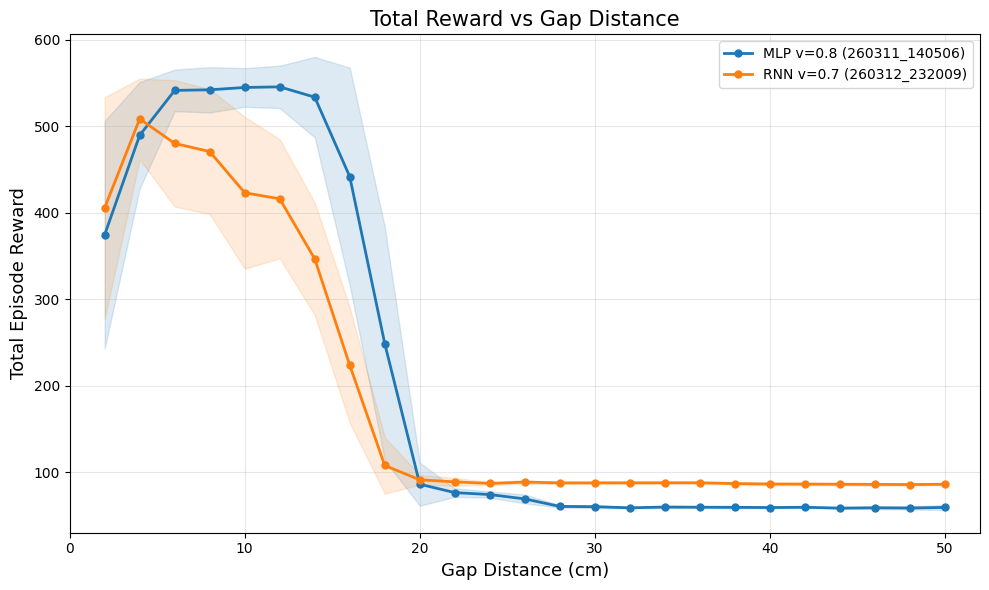

: 

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for run_id, info in CHECKPOINTS.items():
    results = all_results[run_id]
    gaps = sorted(results.keys())
    mean_reward = [results[g]["mean_reward"] for g in gaps]
    std_reward = [results[g]["std_reward"] for g in gaps]
    gaps_cm = [g * 100 for g in gaps]

    ax.plot(
        gaps_cm,
        mean_reward,
        "o-",
        color=info["color"],
        label=f'{info["label"]} ({run_id})',
        linewidth=2,
        markersize=5,
    )
    ax.fill_between(
        gaps_cm,
        np.array(mean_reward) - np.array(std_reward),
        np.array(mean_reward) + np.array(std_reward),
        alpha=0.15,
        color=info["color"],
    )

ax.set_xlabel("Gap Distance (cm)", fontsize=13)
ax.set_ylabel("Total Episode Reward", fontsize=13)
ax.set_title("Total Reward vs Gap Distance", fontsize=15)
ax.set_xlim(0, GAP_DISTANCES.max() * 100 + 2)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Save Results

Save the raw results dict so they can be reloaded without re-running
the sweep.

In [ ]:
import pickle

output_dir = Path(
    "/home/talmolab/Desktop/SalkResearch/vnl-playground/notebooks/gaps-related"
)


# Convert numpy floats to Python floats for JSON serialization
def _to_serializable(obj):
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, dict):
        return {str(k): _to_serializable(v) for k, v in obj.items()}
    return obj


serializable_results = _to_serializable(all_results)

json_path = output_dir / "gap_distance_sweep_results.json"
with open(json_path, "w") as f:
    json.dump(serializable_results, f, indent=2)
print(f"Saved JSON results to: {json_path}")

# Also save as pickle for exact numpy arrays
pkl_path = output_dir / "gap_distance_sweep_results.pkl"
with open(pkl_path, "wb") as f:
    pickle.dump(all_results, f)
print(f"Saved pickle results to: {pkl_path}")